In [1]:
!pip install plotly

In [ ]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.express as px

FILTERED_CSV = "../data/processed/vehicle_points_filtered_buffer250ft.csv"
OUT_DIR = "../visualizations"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(FILTERED_CSV)

# types
df["route_id"] = df["route_id"].astype(str)
df["time"] = pd.to_numeric(df["time"], errors="coerce")
df["speed"] = pd.to_numeric(df["speed"], errors="coerce")

# clean
df = df.dropna(subset=["lat", "lon", "time", "speed", "route_id"])
df = df[df["speed"] >= 0]

df["dt"] = pd.to_datetime(df["time"], unit="s")

print("rows:", len(df))
print("routes:", sorted(df["route_id"].unique()))
df.head()

rows: 80834
routes: ['22', '23', '25', '60', 'Rapid 522', 'Rapid 523']


,bus_id,trip_id,route_id,lat,lon,time,speed,direction,geometry,route_name,dt
0,0130,3926083,60,37.377636,-121.912811,1774546301,4.379942,1,POINT (6151165.292360688 1963070.8272746603),60,2026-03-26 17:31:41
1,0131,3926019,60,37.353451,-121.937241,1774546301,0.002058,0,POINT (6143932.523658695 1954374.025882635),22,2026-03-26 17:31:41
2,0133,3926017,60,37.381004,-121.907265,1774546301,12.524041,0,POINT (6152795.212451222 1964272.847735909),60,2026-03-26 17:31:41
3,0134,3926080,60,37.294777,-121.950005,1774546301,9.549550,1,POINT (6139891.971238612 1933070.4669591582),60,2026-03-26 17:31:41
4,0136,3926086,60,37.410069,-121.891594,1774546301,0.001029,1,POINT (6157505.27503901 1974785.9976167218),60,2026-03-26 17:31:41


Saved: ../03-output-graphics/chart1b_moving_speed_boxplot_gt1.0.png


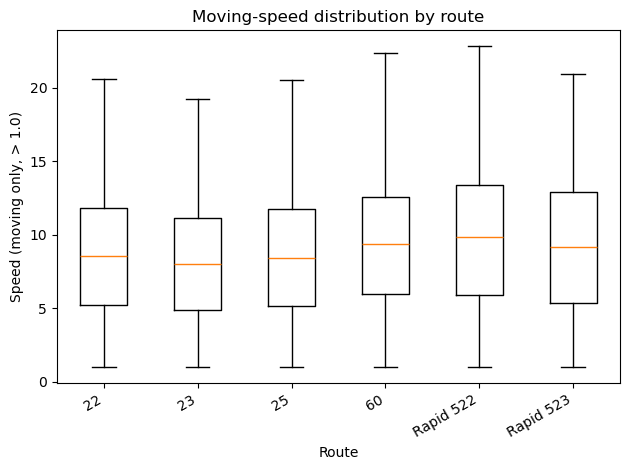

In [8]:
MOVING_TH = 1.0
df_move = df[df["speed"] > MOVING_TH].copy()

routes_order = sorted(df_move["route_id"].unique(), key=lambda x: (x.startswith("Rapid"), x))
data = [df_move.loc[df_move["route_id"] == r, "speed"].values for r in routes_order]

plt.figure()
plt.boxplot(data, tick_labels=routes_order, showfliers=False)
plt.xlabel("Route")
plt.ylabel(f"Speed (moving only, > {MOVING_TH})")
plt.title("Moving-speed distribution by route")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

out_path = os.path.join(OUT_DIR, f"chart1b_moving_speed_boxplot_gt{MOVING_TH}.png")
plt.savefig(out_path, dpi=200)
print("Saved:", out_path)
plt.show()

Saved: ../03-output-graphics/chart2_speed_timeseries_5min.png


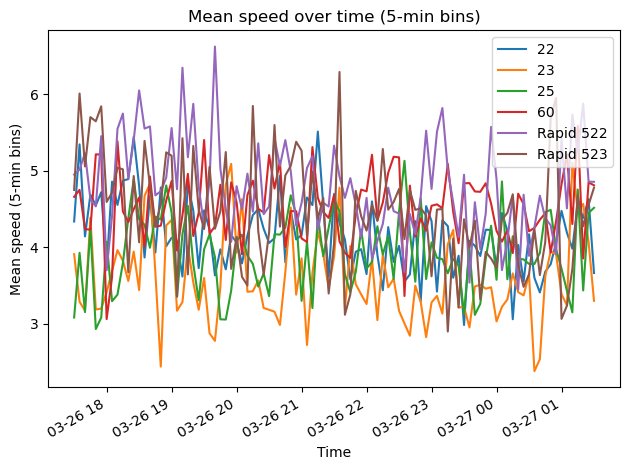

In [16]:
df["time_bin"] = df["dt"].dt.floor("5min")

ts = (
    df.groupby(["route_id","time_bin"])["speed"]
      .mean()
      .reset_index()
)

plt.figure()
for r in routes_order:
    sub = ts[ts["route_id"] == r].sort_values("time_bin")
    plt.plot(sub["time_bin"], sub["speed"], label=r)

plt.xlabel("Time")
plt.ylabel("Mean speed (5-min bins)")
plt.title("Mean speed over time (5-min bins)")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()

out_path = os.path.join(OUT_DIR, "chart2_speed_timeseries_5min.png")
plt.savefig(out_path, dpi=200)
print("Saved:", out_path)
plt.show()

Saved: ../03-output-graphics/chart3_stop_share_th0.5.png


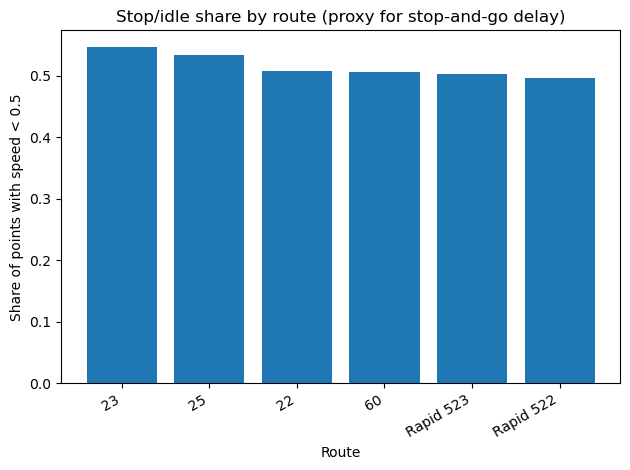

,route_id,stop_share
1,23,0.546853
2,25,0.534300
0,22,0.508656
3,60,0.505632
5,Rapid 523,0.503105
4,Rapid 522,0.497167


In [17]:
STOP_TH = 0.5

stop_share = (
    df.assign(is_stop=df["speed"] < STOP_TH)
      .groupby("route_id")["is_stop"]
      .mean()
      .reset_index()
      .rename(columns={"is_stop":"stop_share"})
      .sort_values("stop_share", ascending=False)
)

plt.figure()
plt.bar(stop_share["route_id"], stop_share["stop_share"])
plt.xlabel("Route")
plt.ylabel(f"Share of points with speed < {STOP_TH}")
plt.title("Stop/idle share by route (proxy for stop-and-go delay)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

out_path = os.path.join(OUT_DIR, f"chart3_stop_share_th{STOP_TH}.png")
plt.savefig(out_path, dpi=200)
print("Saved:", out_path)
plt.show()

stop_share

Saved: ../03-output-graphics/chart4_hotspots_overlay_grid500ft.png


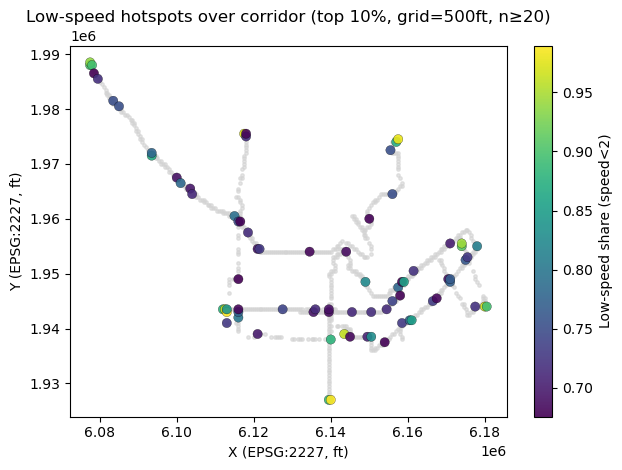

In [21]:
thr = grid["low_share"].quantile(0.9)
hot = grid[grid["low_share"] >= thr].copy()

plt.figure()

# 背景：所有格子（灰色小点）
plt.scatter(grid["gx"], grid["gy"], s=6, color="lightgray", alpha=0.6)

# 前景：热点（彩色）
sc = plt.scatter(
    hot["gx"], hot["gy"],
    s=45,
    c=hot["low_share"],
    alpha=0.9,
    edgecolors="black",
    linewidths=0.2
)
plt.colorbar(sc, label=f"Low-speed share (speed<{LOW_SPEED_TH})")
plt.xlabel("X (EPSG:2227, ft)")
plt.ylabel("Y (EPSG:2227, ft)")
plt.title(f"Low-speed hotspots over corridor (top 10%, grid={GRID_FT}ft, n≥{MIN_N})")
plt.tight_layout()

out_path = os.path.join(OUT_DIR, f"chart4_hotspots_overlay_grid{GRID_FT}ft.png")
plt.savefig(out_path, dpi=200)
print("Saved:", out_path)
plt.show()

Saved: ../03-output-graphics/map_grid_stopshare_1200ft.html


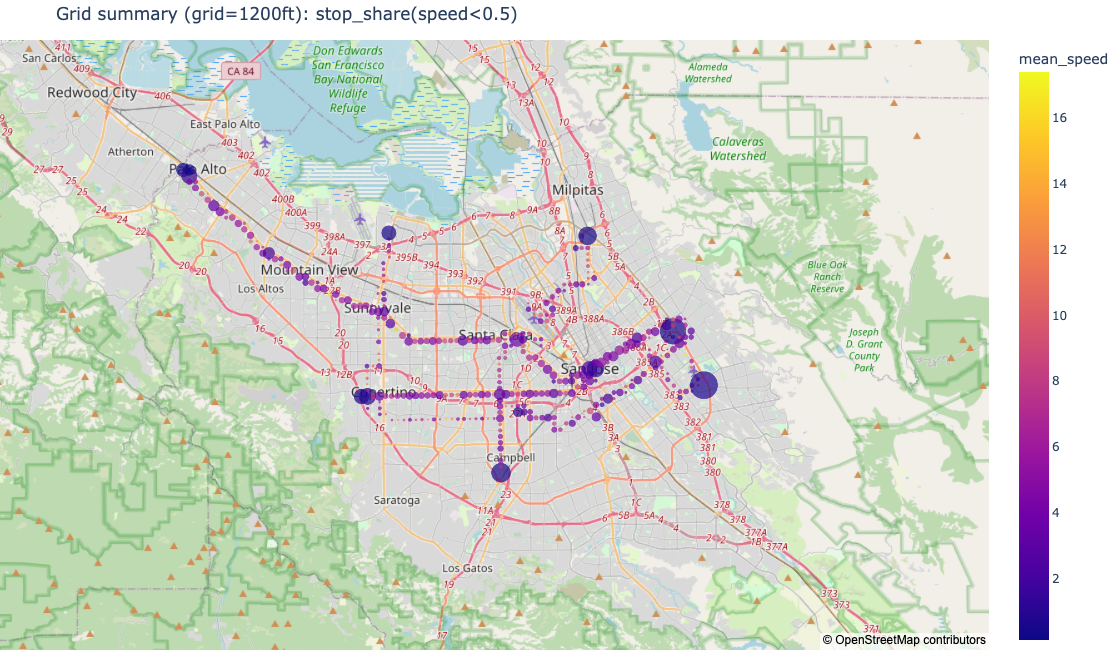

In [12]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"
).to_crs("EPSG:2227")

GRID_FT = 1200  
gdf["gx"] = (gdf.geometry.x // GRID_FT) * GRID_FT
gdf["gy"] = (gdf.geometry.y // GRID_FT) * GRID_FT

STOP_TH = 0.5
gdf["is_stop"] = gdf["speed"] < STOP_TH

grid = (
    gdf.groupby(["gx", "gy"])
       .agg(
           mean_speed=("speed", "mean"),
           stop_share=("is_stop", "mean"),
           n=("speed", "size"),
       )
       .reset_index()
)


grid = grid[grid["n"] >= 20].copy()

# back to lat/lon for mapping
grid_gdf = gpd.GeoDataFrame(
    grid,
    geometry=gpd.points_from_xy(grid["gx"], grid["gy"]),
    crs="EPSG:2227"
).to_crs("EPSG:4326")
grid_gdf["lat"] = grid_gdf.geometry.y
grid_gdf["lon"] = grid_gdf.geometry.x

import plotly.express as px
fig = px.scatter_map(
    grid_gdf,
    lat="lat",
    lon="lon",
    size="n",
    color="mean_speed",          
    hover_data=["mean_speed", "stop_share", "n"],
    zoom=10,
    height=650,
    title=f"Grid summary (grid={GRID_FT}ft): stop_share(speed<{STOP_TH})"
)
fig.update_layout(map_style="open-street-map", margin={"r":0,"t":40,"l":0,"b":0})

out_html = os.path.join(OUT_DIR, f"map_grid_stopshare_{GRID_FT}ft.html")
fig.write_html(out_html)
print("Saved:", out_html)
fig.show()